## Introduction
The heterogeneity of responses to resistance exercise training (RT) is well documented, yet most protocol adopts a one-size-fits-all approach. To be able to offer personalised RT regimens, this study is aimed at predicting individual hypertrophic response to RT based on muscle transcriptomic data of the 460 vastus lateralis samples obtained from 232 participants. 

Three different predition models  each having a balanced accuracy of approximately 0.6 were stacked to build a single model hoping to improve the model's ability to classify an individual as a potential non-responder, average_responder or high_responder

In [229]:
# Load the datasets to be used
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer, StandardScaler
import tensorflow as tf
from tensorflow.keras import  regularizers, callbacks
from tensorflow.python.keras.utils.vis_utils import plot_model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, Concatenate, LeakyReLU, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback

# tf-explain for visual explanations
from tf_explain.core.gradients_inputs import GradientsInputs


from scipy.stats import norm
from scipy import stats
import lime
from lime.lime_tabular import LimeTabularExplainer
from interpret.blackbox import LimeTabular
from interpret import show
from lazypredict.Supervised import LazyClassifier
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
from sklearn.metrics import (classification_report, accuracy_score, f1_score, balanced_accuracy_score,
roc_auc_score, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score, matthews_corrcoef)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import PCA
import shap

# lightgbm_multiclass_tuning.py

from typing import Dict, Any, Tuple, Optional
from dataclasses import dataclass

import lightgbm as lgb
from lightgbm import LGBMClassifier
import joblib
import seaborn as sns

The dataset has been preprocessed to classify those with less than 1% percentage change in muscle mass as "No_responders", those at the 90th percentile and above of the percentage changes in the individual studies as "High_responders"; while the rest are classified as "Average_responders". The preprocessing steps is as shown in the file "Preprocessing.ipynb". 

This data contains the gene expression counts (normalised for library size), age, sample_id, BMI, of participants as well as RNA sequencing_depth of each study ; and volume of RT

In [2]:
# load the dataset.
df = pd.read_csv("./dataset_for_classification_model.csv")
df

,seq_sample_id,age,BMI,category,sequencing_depth,volume,TSPAN6,DPM1,SCYL3,CFH,...,ENSG00000309174,ENSG00000309618,ENSG00000310376,CAST,ENSG00000310523,WASH7P,WASH9P,ENSG00000310533,sex_female,sex_male
0,FP11w0L,22.30,23.60,No_responder,1.51,1,3.85,30.23,8.50,15.33,...,2.95,5.89,1125.84,230.96,5.93,11.60,5.07,1.88,0,1
1,FP11w0R,22.30,23.60,No_responder,1.51,3,4.72,27.63,9.59,19.16,...,3.75,4.72,1057.75,243.95,5.91,11.36,3.96,2.30,0,1
2,FP12w0L,21.30,22.80,No_responder,1.51,1,5.48,32.51,6.23,15.13,...,2.91,7.09,614.65,143.06,7.21,7.53,7.33,2.78,1,0
3,FP12w0R,21.30,22.80,No_responder,1.51,3,5.88,28.35,5.72,16.30,...,2.41,10.94,584.76,142.61,7.23,15.26,9.02,1.10,1,0
4,FP13w0L,22.70,19.80,High_responder,1.51,3,5.59,34.57,4.74,9.17,...,2.29,6.95,724.77,158.42,3.87,16.90,13.56,5.87,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456,s891,54.00,21.80,Average_responder,2.35,3,3.94,18.93,7.06,10.28,...,4.78,1.79,12.13,131.02,17.86,29.32,28.00,3.93,1,0
457,s903,42.00,27.30,High_responder,2.35,3,4.37,18.69,7.91,15.64,...,3.86,2.01,12.21,126.66,13.64,27.64,18.58,1.20,1,0
458,s903,42.00,27.30,Average_responder,2.35,3,4.37,18.69,7.91,15.64,...,3.86,2.01,12.21,126.66,13.64,27.64,18.58,1.20,1,0
459,s96,48.00,27.70,Average_responder,2.35,3,4.69,25.65,7.67,13.27,...,1.94,1.73,37.61,151.40,15.83,24.10,27.72,3.25,0,1


In [3]:
# Define the random state configuration for all
RANDOM_STATE = 123

In [4]:

# Drop sample_id and category columns to define others as predictor variables
X = df.drop(["seq_sample_id", "category"], axis=1)

# Encode the response variable
y = df["category"].map({'No_responder': 0, 'Average_responder': 1, 'High_responder': 2})

# Split into training and test sets
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Split training dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train_full
)
# Columns to exclude from scaling
exclude_cols = ["BMI", "age",  "volume", "sex_female", "sex_male"]

# Separate columns to scale
X_train_to_scale = X_train.drop(columns=exclude_cols)
X_val_to_scale = X_val.drop(columns=exclude_cols)
X_test_to_scale = X_test.drop(columns=exclude_cols)

# Scale only the selected columns
scaler = StandardScaler()
X_train_scaled_part = scaler.fit_transform(X_train_to_scale)
X_val_scaled_part = scaler.transform(X_val_to_scale)
X_test_scaled_part = scaler.transform(X_test_to_scale)

# Convert scaled arrays back to DataFrames
X_train_scaled_part = pd.DataFrame(X_train_scaled_part, columns=X_train_to_scale.columns, index=X_train.index)
X_val_scaled_part = pd.DataFrame(X_val_scaled_part, columns=X_val_to_scale.columns, index=X_val.index)
X_test_scaled_part = pd.DataFrame(X_test_scaled_part, columns=X_test_to_scale.columns, index=X_test.index)

# Reappend the excluded columns
X_train_scaled = pd.concat([X_train_scaled_part, X_train[exclude_cols]], axis=1)
X_val_scaled = pd.concat([X_val_scaled_part, X_val[exclude_cols]], axis=1)
X_test_scaled = pd.concat([X_test_scaled_part, X_test[exclude_cols]], axis=1)

# Print shapes
print(f"Training feature shape: {X_train_scaled.shape}")
print(f"Validation feature shape: {X_val_scaled.shape}")
print(f"Test feature shape: {X_test_scaled.shape}")


Training feature shape: (294, 11231)
Validation feature shape: (74, 11231)
Test feature shape: (93, 11231)


In [5]:
def build_multiclass_model(input_shape, num_classes):
    """Builds a sequential model for multi-class classification."""
    model = Sequential([
        Input(shape=input_shape),
        
        
        # Hidden Layer 1
       Dense(512, kernel_regularizer=regularizers.l2(1e-6)),
       Activation('relu'),
        BatchNormalization(),
      #  Dropout(0.5), # Using a slightly higher dropout rate

        
        # Hidden Layer 2
      Dense(256,  kernel_regularizer=regularizers.l2(1e-6)),
        Activation('relu'),
        BatchNormalization(),
     #  Dropout(0.4),

        # Hidden Layer 3
        Dense(128,  kernel_regularizer=regularizers.l2(1e-6)),
       Activation('relu'),
        BatchNormalization(),
      #  Dropout(0.3),
        
         # Hidden Layer 4
        Dense(64,  kernel_regularizer=regularizers.l2(1e-5)),
         Activation('relu'),
        Dense(num_classes, activation='softmax')  # Multi-class classification
    ]) 
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits = False),  # cos labels are encoded as integers
                  metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")])
    
    return model


In [6]:
# Get the input shape from the training data
input_shape = (X_train_scaled.shape[1],)
model = build_multiclass_model(input_shape, 3)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │       5,750,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,927,043 (22.61 MB)

 Trainable params: 5,925,251 (22.60 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [7]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

In [8]:
class ValMacroF1(Callback):
    def __init__(self, Xv, yv, name='val_macro_f1'):
        super().__init__(); self.Xv, self.yv, self.name = Xv, yv, name
    def on_epoch_end(self, epoch, logs=None):
        y_prob = self.model.predict(self.Xv, verbose=0)
        y_pred = y_prob.argmax(axis=1)
        macro_f1 = f1_score(self.yv, y_pred, average='macro')
        logs[self.name] = macro_f1
        print(f" — {self.name}: {macro_f1:.4f}")

 
val_macro_f1_cb = ValMacroF1(X_val_scaled, y_val) # macro F1 score gives equal weight to each class in imbalanced datasets

early_stopping = EarlyStopping(
    monitor='val_macro_f1', 
    mode='max',
    patience=12, restore_best_weights=True, verbose=1 ,
    min_delta = 0.002 # only react to improvesments at or above 0.002
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_macro_f1', mode = "max",  factor=0.5, patience=3,
    min_lr=1e-5, verbose=1,
     min_delta = 0.002 
)

ckpt = ModelCheckpoint("best_weight_model.keras", monitor="val_macro_f1",
                       mode="max",
                       save_best_only=True, verbose=1)

history = model.fit(
    X_train_scaled, y_train,  # or X_train_scaled, y_train if using class weights
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    callbacks=[val_macro_f1_cb, 
               early_stopping, 
               reduce_lr, ckpt],
    verbose=1,
    class_weight = class_weight_dict
)

Epoch 1/200
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4611 - loss: 1.2984 — val_macro_f1: 0.2688

Epoch 1: val_macro_f1 improved from None to 0.26882, saving model to best_weight_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.4864 - loss: 1.3768 - val_accuracy: 0.6757 - val_loss: 1.1202 - val_macro_f1: 0.2688 - learning_rate: 3.0000e-04
Epoch 2/200
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6763 - loss: 0.6504 — val_macro_f1: 0.3924

Epoch 2: val_macro_f1 improved from 0.26882 to 0.39240, saving model to best_weight_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.6395 - loss: 0.7035 - val_accuracy: 0.7027 - val_loss: 1.1779 - val_macro_f1: 0.3924 - learning_rate: 3.0000e-04
Epoch 3/200
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7368 - loss: 0.5718 — val_macro_f1: 0.3641

Epoch 3: val_macro_f1 did not improve from 0.39240
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.7041 - loss: 0.6052 - val_accuracy: 0.689

In [9]:
best_model = tf.keras.models.load_model("best_weight_model.keras")
def evaluate_and_visualize_split(name, X_split, y_split, class_names, plot_roc_pr=True, save_figs=False, prefix="",
                                compute_shap = False, shap_explainer = None, shap_sample_n = 300,
                                shap_classes = None, shap_local_topk = 2,
                                feature_names = None):
    """
    name: 'Validation' or 'Test'
    X_split: scaled features
    y_split: integer labels (0..C-1)
    """
    proba = best_model.predict(X_split, verbose=0)           # (n, C)
    y_pred = np.argmax(proba, axis=1)
    conf   = proba.max(axis=1)                          # max softmax as confidence
    C      = proba.shape[1]

    # --- Metrics ---
    acc  = accuracy_score(y_split, y_pred)
    f1m  = f1_score(y_split, y_pred, average='macro', zero_division=0)
    bacc = balanced_accuracy_score(y_split, y_pred)
    try:
        aucm = roc_auc_score(y_split, proba, multi_class='ovr', average='macro')
    except Exception:
        aucm = np.nan

    # NEW: MCC (multi-class)
    mcc = matthews_corrcoef(y_split, y_pred)

    print(f"\n=== {name} Metrics ===")
    print(f"Accuracy:            {acc:.3f}")
    print(f"Macro-F1:            {f1m:.3f}")
    print(f"Balanced Accuracy:   {bacc:.3f}")
    print(f"Macro ROC-AUC (OVR): {aucm:.3f}")
    print(f"MCC (multi-class):   {mcc:.3f}")
    print("\nClassification report:")
    print(classification_report(y_split, y_pred, target_names=class_names, digits=3, zero_division=0))

    # (Optional) One-vs-Rest MCC per class
    try:
        mcc_per_class = []
        for k in range(C):
            y_true_bin = (y_split == k).astype(int)
            y_pred_bin = (y_pred == k).astype(int)
            mcc_k = matthews_corrcoef(y_true_bin, y_pred_bin)
            mcc_per_class.append(mcc_k)
        print("OvR MCC per class:  " + ", ".join(f"{name}={val:.3f}" for name, val in zip(class_names, mcc_per_class)))
    except Exception as e:
        print(f"(Per-class MCC skipped: {e})")

    # --- Confusion matrix (counts) ---
    cm = confusion_matrix(y_split, y_pred, labels=np.arange(C))

    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax[0])
    ax[0].set_title(f'{name} Confusion Matrix')
    ax[0].set_xlabel('Predicted')
    ax[0].set_ylabel('Actual')
     # Fixed: put jitter on a new line
    jitter = 0.12
    x_j = y_split + np.random.uniform(-jitter, jitter, size=y_split.shape)
    y_j = y_pred  + np.random.uniform(-jitter, jitter, size=y_pred.shape)

    sc = ax[1].scatter(x_j, y_j, c=conf, cmap='viridis', s=40, alpha=0.8, edgecolor='k', linewidth=0.2)
    ax[1].plot([-0.5, C-0.5], [-0.5, C-0.5], 'r--', lw=1)  # perfect predictions diagonal
    ax[1].set_xticks(range(C)); ax[1].set_yticks(range(C))
    ax[1].set_xticklabels(class_names, rotation=45, ha='right'); ax[1].set_yticklabels(class_names)
    ax[1].set_xlim([-0.5, C-0.5]); ax[1].set_ylim([-0.5, C-0.5])
    ax[1].set_title(f'{name} Scatter: Predicted vs Actual\n(color = max softmax)')
    ax[1].set_xlabel('Actual class'); ax[1].set_ylabel('Predicted class')
    cbar = plt.colorbar(sc, ax=ax[1]); cbar.set_label('Max predicted probability')
    plt.tight_layout()
    if save_figs:
        plt.savefig(f"{prefix}{name.lower()}_confusion_and_scatter.png", dpi=200, bbox_inches='tight')
    plt.show()

    # --- Optional: ROC & Precision-Recall curves (one-vs-rest) ---
    if plot_roc_pr:
        try:
            y_bin = label_binarize(y_split, classes=np.arange(C))

            # ROC curves
            from itertools import cycle
            colors = cycle(["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"])
            fig, ax = plt.subplots(figsize=(7, 6))
            for i, color in zip(range(C), colors):
                fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
                roc_auc = auc(fpr, tpr)
                ax.plot(fpr, tpr, color=color, lw=2, label=f"{class_names[i]} (AUC={roc_auc:.2f})")
            ax.plot([0,1],[0,1], 'k--', lw=1)
            ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate", title=f"ROC Curves ({name}, OVR)")
            ax.legend(loc="lower right")
            plt.tight_layout()
            if save_figs:
                plt.savefig(f"{prefix}{name.lower()}_roc_curves.png", dpi=200, bbox_inches='tight')
            plt.show()
            # Precision-Recall curves
            colors = cycle(["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"])
            fig, ax = plt.subplots(figsize=(7, 6))
            for i, color in zip(range(C), colors):
                precision, recall, _ = precision_recall_curve(y_bin[:, i], proba[:, i])
                ap = average_precision_score(y_bin[:, i], proba[:, i])
                ax.plot(recall, precision, color=color, lw=2, label=f"{class_names[i]} (AP={ap:.2f})")
            ax.set(xlabel="Recall", ylabel="Precision", title=f"Precision‑Recall Curves ({name}, OVR)")
            ax.legend(loc="lower left")
            plt.tight_layout()
            if save_figs:
                plt.savefig(f"{prefix}{name.lower()}_pr_curves.png", dpi=200, bbox_inches='tight')
            plt.show()
        except Exception as e:
            print(f"(ROC/PR plotting skipped: {e})")

    # ... inside SHAP section:
    if compute_shap:
        if feature_names is None:
            feature_names = [f"f{i}" for i in range(X_split.shape[1])]
        # Convert X_split to DataFrame for SHAP
        import pandas as pd
        X_split_df = pd.DataFrame(X_split, columns=feature_names)
        # Then use X_split_df for SHAP explainer



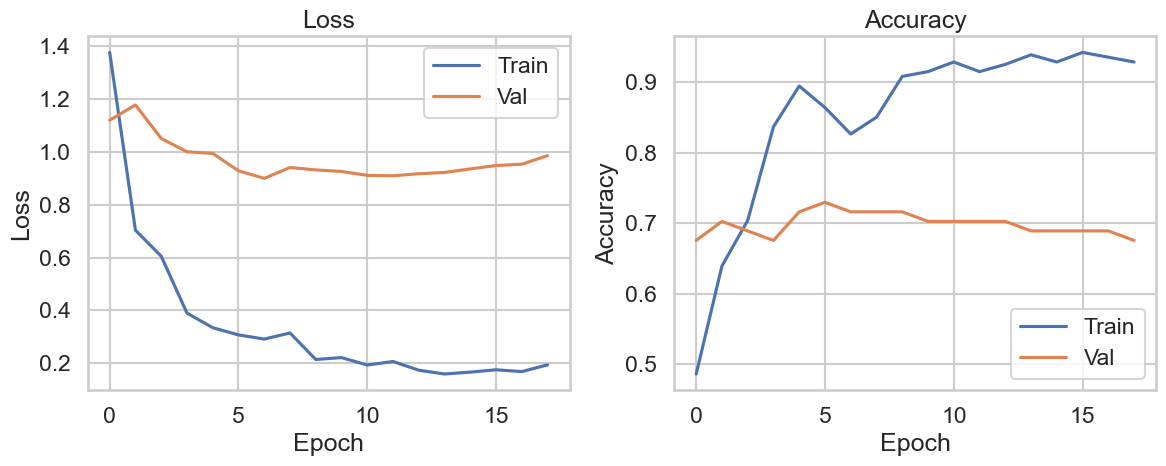

In [10]:
# Metrics & Visualizations 
sns.set(style="whitegrid", context="talk")

# Recover readable class names in the correct order (0,1,2) from your mapping
category_mapping = {'No_responder': 0, 'Average_responder': 1, 'High_responder': 2}
inv_map = {v: k for k, v in category_mapping.items()}
class_names = [inv_map[i] for i in range(len(inv_map))]  # ['No_responder','Average_responder','High_responder']

# ---- 5A) Training curves (loss & accuracy) ----
hist_df = pd.DataFrame(history.history)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# Loss
ax[0].plot(hist_df['loss'], label='Train')
if 'val_loss' in hist_df:
    ax[0].plot(hist_df['val_loss'], label='Val')
ax[0].set_title('Loss'); ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss')
ax[0].legend()

# Accuracy
if 'accuracy' in hist_df:
    ax[1].plot(hist_df['accuracy'], label='Train')
if 'val_accuracy' in hist_df:
    ax[1].plot(hist_df['val_accuracy'], label='Val')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Accuracy')
ax[1].legend()
plt.tight_layout()
plt.show()


=== Validation Metrics ===
Accuracy:            0.730
Macro-F1:            0.530
Balanced Accuracy:   0.488
Macro ROC-AUC (OVR): 0.596
MCC (multi-class):   0.282

Classification report:
                   precision    recall  f1-score   support

     No_responder      0.444     0.308     0.364        13
Average_responder      0.762     0.906     0.828        53
   High_responder      1.000     0.250     0.400         8

         accuracy                          0.730        74
        macro avg      0.735     0.488     0.530        74
     weighted avg      0.732     0.730     0.700        74

OvR MCC per class:  No_responder=0.263, Average_responder=0.243, High_responder=0.479


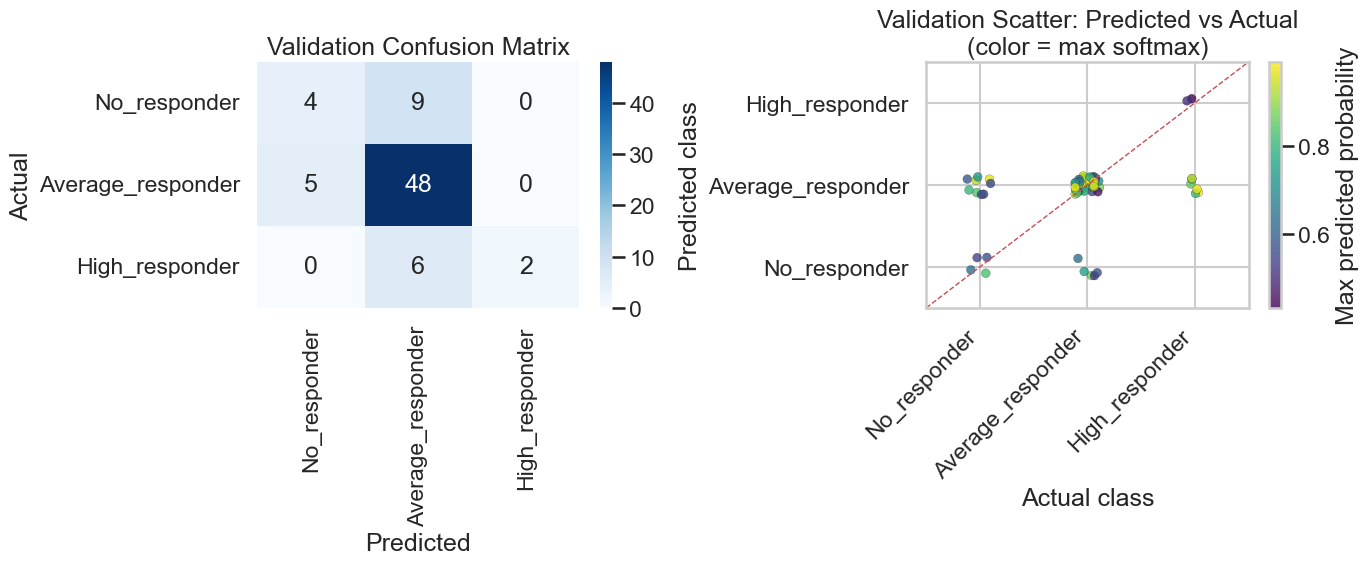

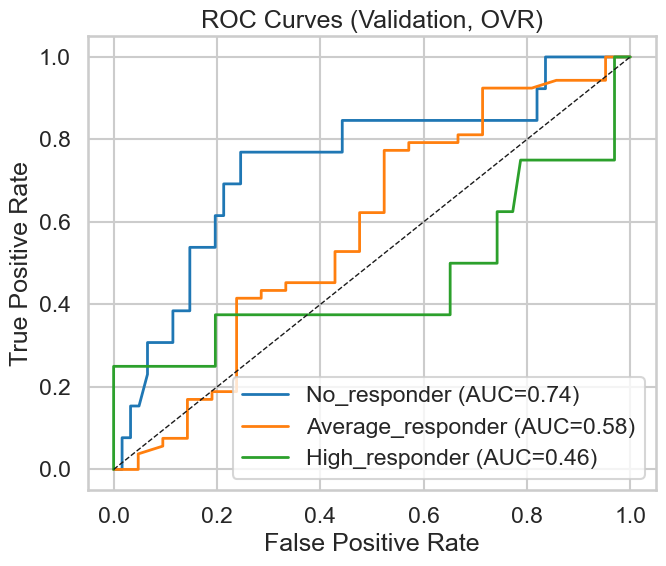

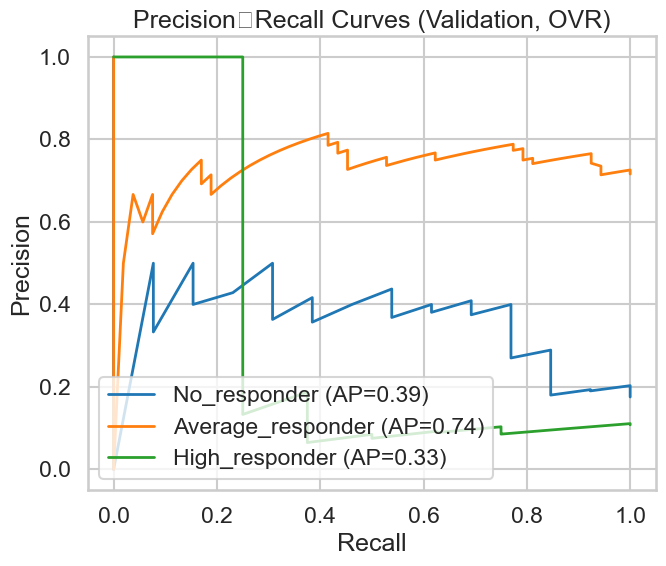


=== Test Metrics ===
Accuracy:            0.634
Macro-F1:            0.425
Balanced Accuracy:   0.413
Macro ROC-AUC (OVR): 0.541
MCC (multi-class):   0.129

Classification report:
                   precision    recall  f1-score   support

     No_responder      0.235     0.235     0.235        17
Average_responder      0.746     0.803     0.774        66
   High_responder      0.400     0.200     0.267        10

         accuracy                          0.634        93
        macro avg      0.461     0.413     0.425        93
     weighted avg      0.616     0.634     0.621        93

OvR MCC per class:  No_responder=0.064, Average_responder=0.146, High_responder=0.225


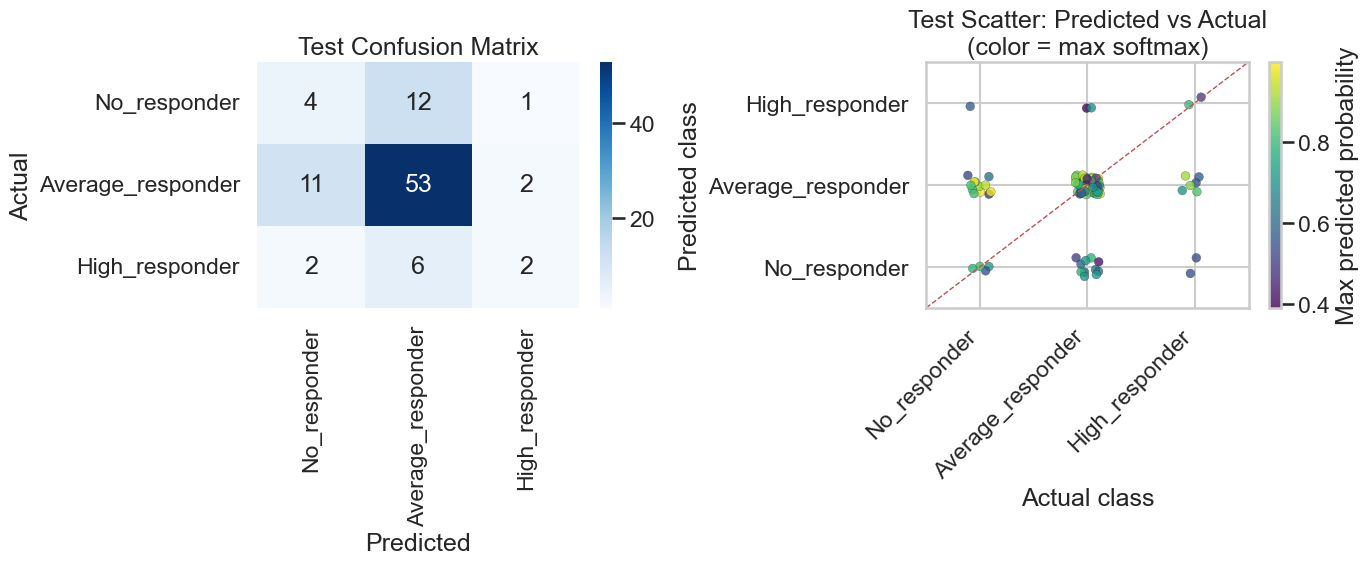

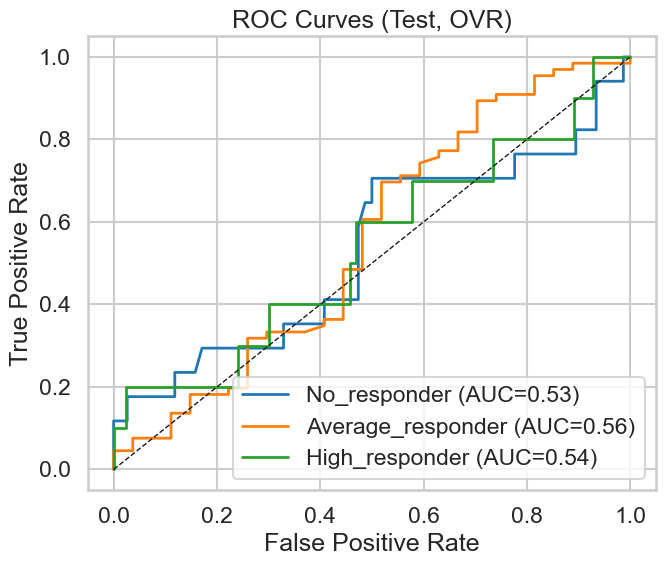

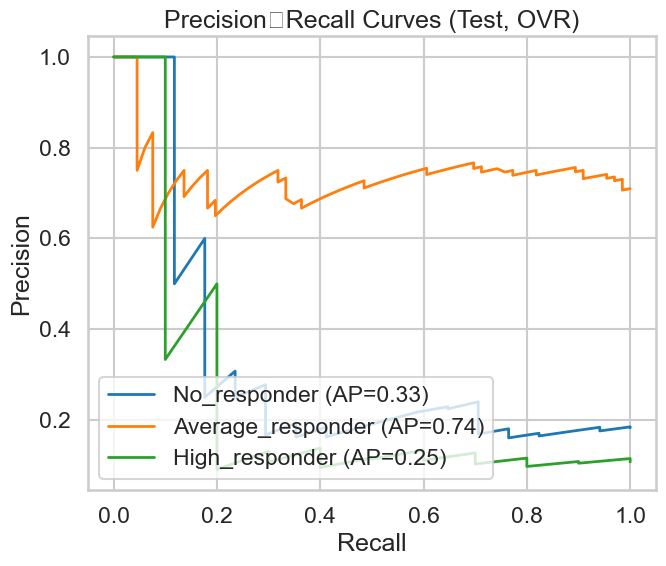

In [11]:
# ---- 5B) Run on Validation ----
evaluate_and_visualize_split("Validation", X_val_scaled, y_val, class_names, plot_roc_pr=True, save_figs=False)

# ---- 5C) Run on Test (if defined) ----
evaluate_and_visualize_split("Test", X_test_scaled, y_test, class_names, plot_roc_pr=True, save_figs=False)

## Modelling using LGBMclassifier

In [34]:
# sklearn-style custom metric suitable for LGBM
def macro_f1_sklearn(y_true, y_pred):
    """
    Custom eval metric for LightGBM scikit-learn API.
    Works for multiclass; accepts raw scores or probabilities.
    Returns (name, value, higher_is_better).
    """
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred)

    # LightGBM may pass:
    # - shape (N, C) (preferred) OR
    # - flattened shape (N*C,)
    if y_pred.ndim == 1:
        n_samples = y_true.shape[0]
        n_classes = int(y_pred.size // n_samples)
        y_prob = y_pred.reshape(n_samples, n_classes)
    else:
        y_prob = y_pred  # (N, C)

    # Argmax produces class predictions (raw score vs prob does not matter for argmax)
    y_hat = y_prob.argmax(axis=1)

    f1 = f1_score(y_true, y_hat, average="macro", zero_division=0)
    return "macro_f1", f1, True


In [35]:
# configuration
USE_GPU = False                   
EARLY_STOPPING_ROUNDS = 100
N_ESTIMATORS_MAX = 5000           # upper bound (early stopping will stop earlier)
N_ITER = 30                       # random search trials
VERBOSE_LGB_EVAL = False          # per-iteration logging off

# Class names 
#idx_to_class = {0: 'No_responder', 1: 'Average_responder', 2: 'High_responder'}
#class_names = [idx_to_class[i] for i in sorted(idx_to_class)]



In [286]:

callbacks = [lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=VERBOSE_LGB_EVAL)]
if not VERBOSE_LGB_EVAL:
    callbacks.append(lgb.log_evaluation(period=0))

lgbm = LGBMClassifier(
    objective="multiclassova",
    #boosting_type= "rf",
    num_class=3,                   
    n_estimators=2000,             # large upper bound; early stopping will cut short
    random_state=RANDOM_STATE,
    n_jobs=-1,         
     class_weight=class_weight_dict,  
    learning_rate=0.05,
    num_leaves=2,
    feature_fraction=0.6,
    bagging_fraction=0.4,
    bagging_freq=4,
    min_data_in_leaf=15,
    lambda_l2=0.11,
    min_gain_to_split= 0.02,
    verbosity = -1 # suppress log output
)


lgbm.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    eval_metric=macro_f1_sklearn,      # <— use sklearn-style custom metric
    callbacks=callbacks,

)

# Evaluate on validation dataset
probs_val = lgbm.predict_proba(X_val_scaled, num_iteration=lgbm.best_iteration_)
pred_val = probs_val.argmax(axis=1)
print(f" Val macro-F1: {f1_score(y_val, pred_val, average='macro'):.4f}")

print(classification_report(
    y_val, pred_val,
    target_names=["No_responder", "Average_responder", "High_responder"],
    digits=3, zero_division=0
))


 Val macro-F1: 0.6325
                   precision    recall  f1-score   support

     No_responder      0.727     0.615     0.667        13
Average_responder      0.817     0.925     0.867        53
   High_responder      0.667     0.250     0.364         8

         accuracy                          0.797        74
        macro avg      0.737     0.597     0.633        74
     weighted avg      0.785     0.797     0.778        74



In [230]:
# save the LGBM model
joblib.dump(lgbm, "lgbm_model.joblib")

['lgbm_model.joblib']

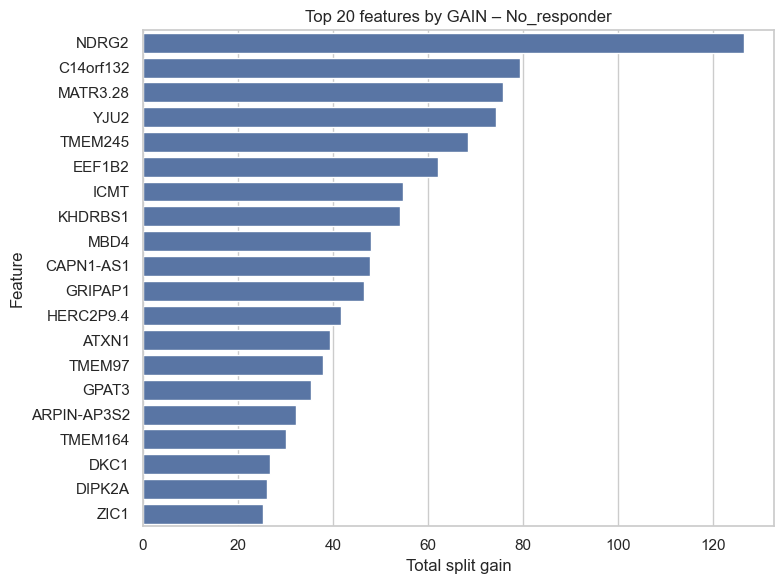

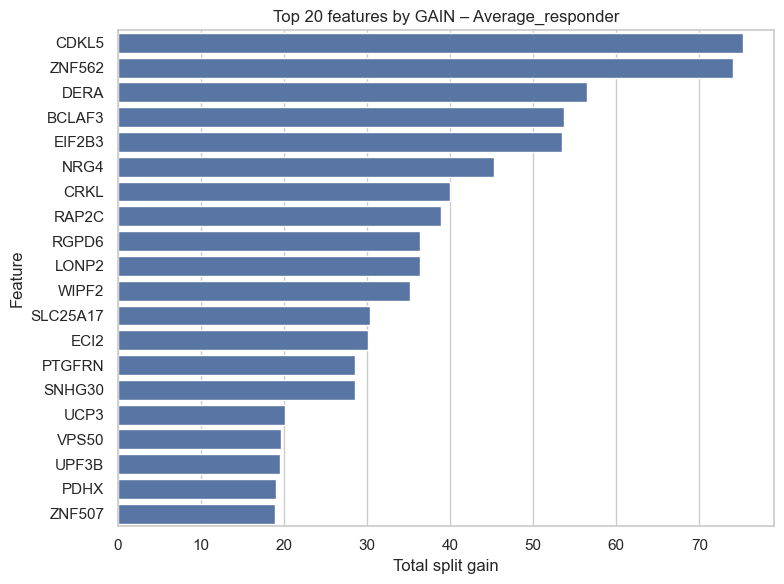

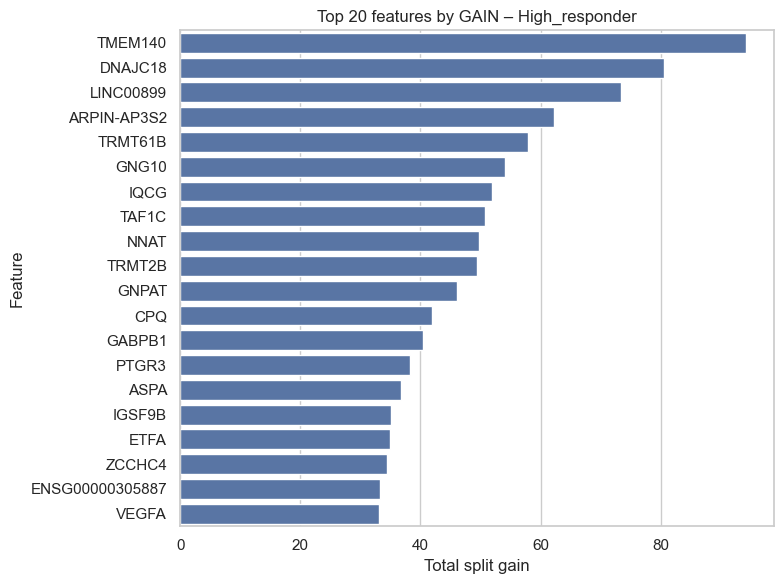

In [294]:
# Trained model: lgbm (sklearn wrapper)
booster = lgbm.booster_
num_class = len(lgbm.classes_)   # should be 3
class_names = ["No_responder", "Average_responder", "High_responder"]

# Extract trees as DataFrame
df_ = booster.trees_to_dataframe()

# Restrict to trees used up to best_iteration
if getattr(lgbm, "best_iteration_", None) is not None:
    df_ = df_[df_["tree_index"] < lgbm.best_iteration_ * num_class]

# Keep only split nodes
df_ = df_[~df_["split_feature"].isna()].copy()

# Map tree
df_["class_id"] = (df_["tree_index"] % num_class).astype(int)

# Aggregate split_gain per (class, feature)
gain_pc = (
    df_.groupby(["class_id", "split_feature"])["split_gain"]
      .sum().reset_index().rename(columns={"split_gain": "gain"})
)

# Plot top-K per class
TOP_K = 20
sns.set(style="whitegrid")
for c in range(num_class):
    data = (gain_pc[gain_pc["class_id"] == c]
            .sort_values("gain", ascending=False).head(TOP_K))
    plt.figure(figsize=(8, max(4, 0.3*len(data))))
    sns.barplot(data=data, y="split_feature", x="gain", color="#4C72B0")
    plt.title(f"Top {TOP_K} features by GAIN – {class_names[c]}")
    plt.xlabel("Total split gain")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()


gain_pc["class_name"] = gain_pc["class_id"].map({i:n for i,n in enumerate(class_names)})
gain_pc.sort_values(["class_id","gain"], ascending=[True,False]).to_csv("lgb_per_class_gain.csv", index=False)


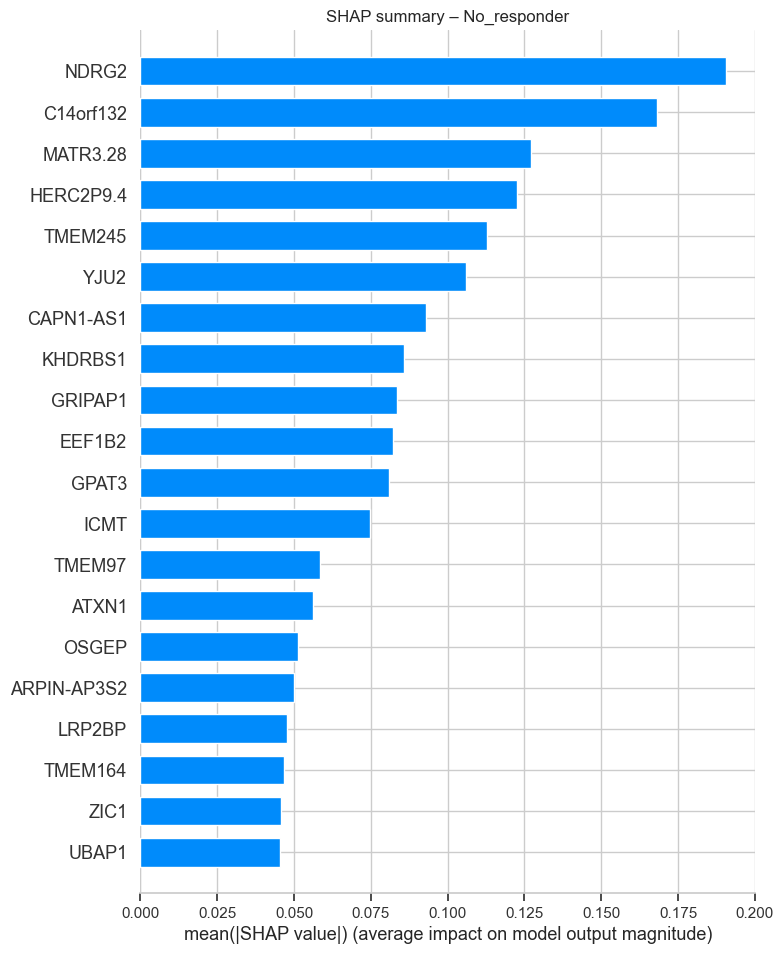

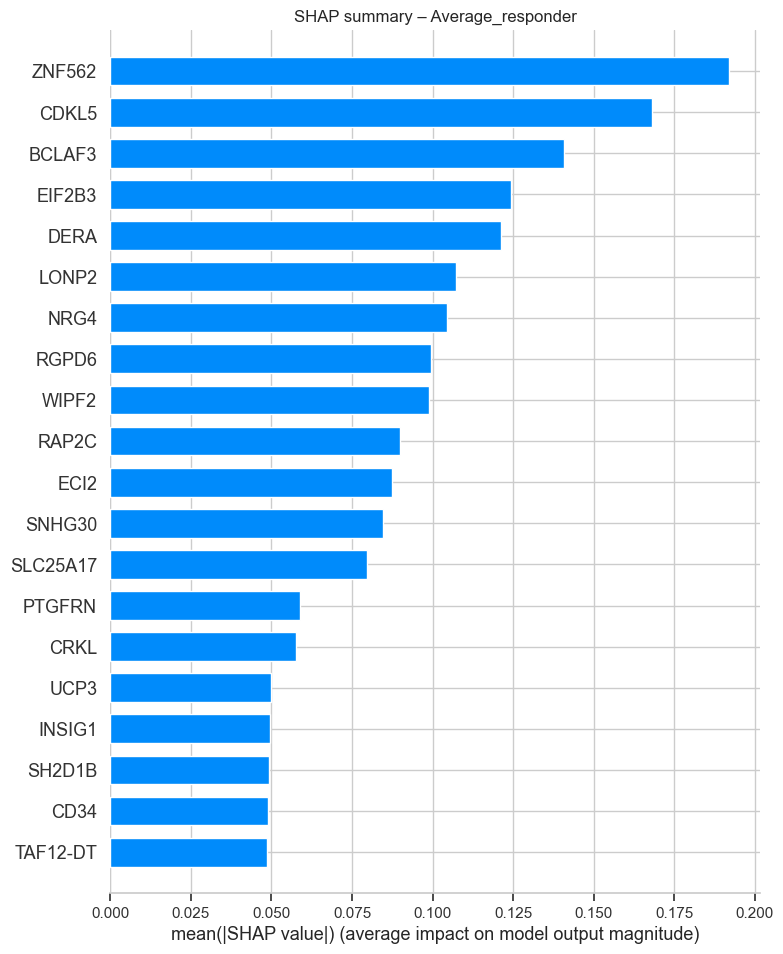

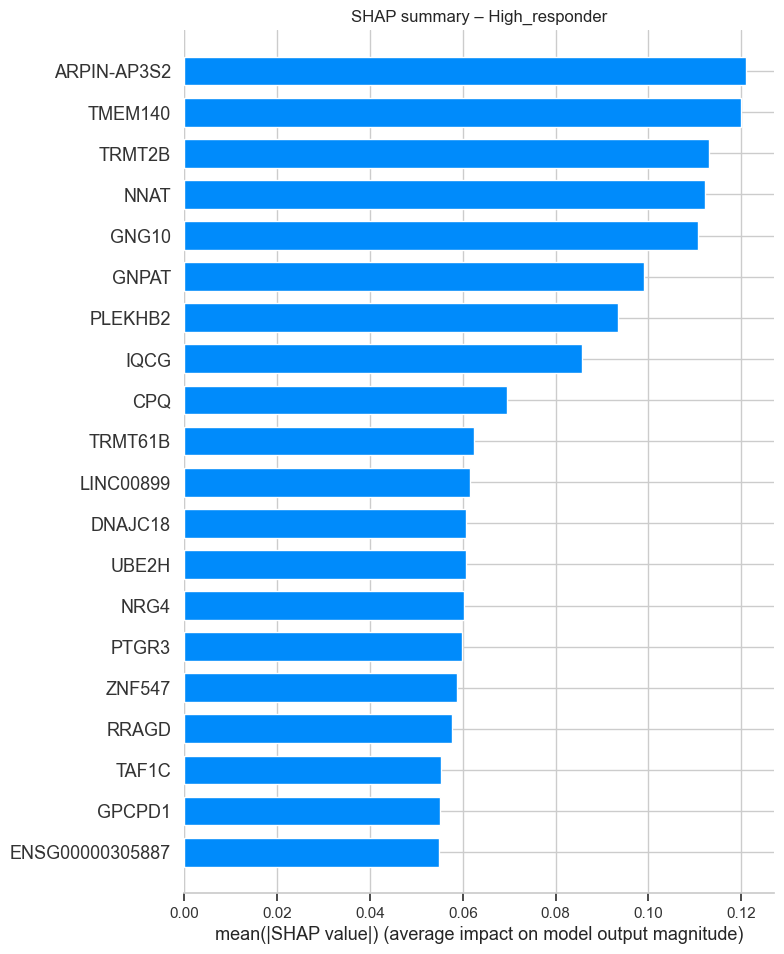

In [318]:


feature_names = lgbm.booster_.feature_name()

explainer = shap.TreeExplainer(lgbm.booster_)
shap_values = explainer.shap_values(X_bg)  # -> (n, d, C) in your setup

for c, name in enumerate(class_names):
    sv_c = shap_values[:, :, c]   # (n, d) for class c
    shap.summary_plot(
        sv_c, X_bg,
        feature_names=feature_names,
        plot_type="bar",      # plot as bar
        max_display=20,       # show top 20 to keep it readable
        show=False
    )
    plt.title(f"SHAP summary – {name}")
    plt.show()



In [330]:
# How many features were relevant for the model
used_features = (lgbm.booster_.feature_importance(importance_type="gain") > 0).sum()
print(f"Features used in splits: {used_features} / {len(lgbm.booster_.feature_name())}")


Features used in splits: 111 / 11231


In [332]:
booster = lgbm.booster_
num_class = len(lgbm.classes_)  # should be 3
class_names = ["No_responder", "Average_responder", "High_responder"]

# All trees as a DataFrame
df_trees = booster.trees_to_dataframe()

# IMPORTANT: respect early stopping (use only trees up to best_iteration_)
if getattr(lgbm, "best_iteration_", None) is not None:
    df_trees = df_trees[df_trees["tree_index"] < lgbm.best_iteration_ * num_class]

# Keep only split rows (ignore leaves)
df_splits = df_trees[~df_trees["split_feature"].isna()].copy()

# Map tree -> class: LightGBM cycles trees across classes
df_splits["class_id"] = (df_splits["tree_index"] % num_class).astype(int)

# Aggregate total split gain per (class, feature)
gain_pc = (
    df_splits.groupby(["class_id", "split_feature"])["split_gain"]
    .sum()
    .reset_index()
    .rename(columns={"split_gain": "gain"})
)

# Long format: one row per (class, feature)
gain_pc["class_name"] = gain_pc["class_id"].map(dict(enumerate(class_names)))
gain_pc = gain_pc.sort_values(["class_id", "gain"], ascending=[True, False]).reset_index(drop=True)
print("\nPer-class gain (long format):")
print(gain_pc.head(15))

# Wide format: one column per class, plus total
df_wide = gain_pc.pivot_table(index="split_feature", columns="class_name", values="gain", fill_value=0)
df_wide["gain_total"] = df_wide.sum(axis=1)
df_wide = df_wide.sort_values("gain_total", ascending=False).reset_index()
df_wide = df_wide.rename(columns={"split_feature": "feature"})
print("\nPer-class gain (wide format):")
print(df_wide.head(15))

# Save if useful
# gain_pc.to_csv("lgb_per_class_gain_long.csv", index=False)
# df_wide.to_csv("lgb_per_class_gain_wide.csv", index=False)



Per-class gain (long format):
    class_id split_feature   gain    class_name
0          0         NDRG2 126.48  No_responder
1          0     C14orf132  79.39  No_responder
2          0      MATR3.28  75.71  No_responder
3          0          YJU2  74.24  No_responder
4          0       TMEM245  68.38  No_responder
5          0        EEF1B2  62.13  No_responder
6          0          ICMT  54.80  No_responder
7          0       KHDRBS1  54.15  No_responder
8          0          MBD4  47.99  No_responder
9          0     CAPN1-AS1  47.80  No_responder
10         0       GRIPAP1  46.51  No_responder
11         0     HERC2P9.4  41.63  No_responder
12         0         ATXN1  39.28  No_responder
13         0        TMEM97  37.98  No_responder
14         0         GPAT3  35.44  No_responder

Per-class gain (wide format):
class_name      feature  Average_responder  High_responder  No_responder  \
0                 NDRG2               0.00            0.00        126.48   
1           ARPIN-

In [333]:
df_wide

class_name,feature,Average_responder,High_responder,No_responder,gain_total
0,NDRG2,0.00,0.00,126.48,126.48
1,ARPIN-AP3S2,0.00,62.17,32.26,94.42
2,TMEM140,0.00,94.19,0.00,94.19
3,DNAJC18,0.00,80.62,0.00,80.62
4,C14orf132,0.00,0.00,79.39,79.39
...,...,...,...,...,...
106,COX10,0.00,0.00,13.05,13.05
107,DERL1,12.57,0.00,0.00,12.57
108,POLR1C,12.35,0.00,0.00,12.35
109,AHCYL1,12.28,0.00,0.00,12.28


In [339]:
top_no = gain_pc[gain_pc["class_name"] == "No_responder"].sort_values("gain", ascending=False)
#print(top_no.head(30))  # Top 30 features for No_responder by gain
top_no

,class_id,split_feature,gain,class_name
0,0,NDRG2,126.48,No_responder
1,0,C14orf132,79.39,No_responder
2,0,MATR3.28,75.71,No_responder
3,0,YJU2,74.24,No_responder
4,0,TMEM245,68.38,No_responder
5,0,EEF1B2,62.13,No_responder
6,0,ICMT,54.80,No_responder
7,0,KHDRBS1,54.15,No_responder
8,0,MBD4,47.99,No_responder
9,0,CAPN1-AS1,47.80,No_responder


In [340]:
# Top 30 features for average responders
top_av = gain_pc[gain_pc["class_name"] == "Average_responder"].sort_values("gain", ascending=False)
#print(top_av.head(30))  # Top 30 features for average_responder by gain
top_av

,class_id,split_feature,gain,class_name
36,1,CDKL5,75.23,Average_responder
37,1,ZNF562,74.05,Average_responder
38,1,DERA,56.43,Average_responder
39,1,BCLAF3,53.70,Average_responder
40,1,EIF2B3,53.51,Average_responder
41,1,NRG4,45.26,Average_responder
42,1,CRKL,40.02,Average_responder
43,1,RAP2C,38.97,Average_responder
44,1,RGPD6,36.46,Average_responder
45,1,LONP2,36.34,Average_responder


In [338]:
# Top 30 features for High responders
top_high = gain_pc[gain_pc["class_name"] == "High_responder"].sort_values("gain", ascending=False)
#print(top_high.head(30))  # Top 30 features for high_responder by gain
top_high

,class_id,split_feature,gain,class_name
73,2,TMEM140,94.19,High_responder
74,2,DNAJC18,80.62,High_responder
75,2,LINC00899,73.39,High_responder
76,2,ARPIN-AP3S2,62.17,High_responder
77,2,TRMT61B,57.84,High_responder
78,2,GNG10,54.09,High_responder
79,2,IQCG,51.91,High_responder
80,2,TAF1C,50.82,High_responder
81,2,NNAT,49.71,High_responder
82,2,TRMT2B,49.34,High_responder


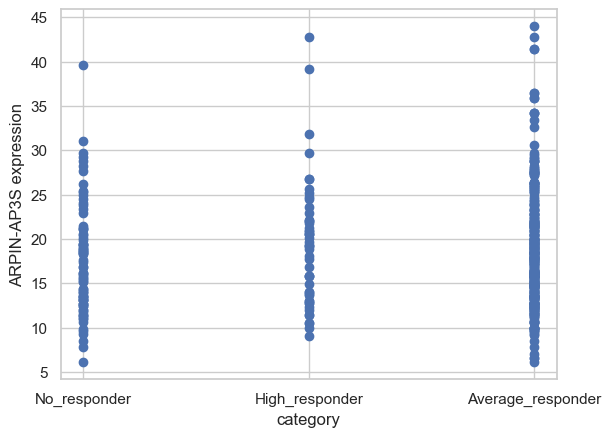

In [329]:
#Extract the important features 
plt.scatter(df["category"], df["TMEM140"])
plt.ylabel('ARPIN-AP3S expression')
plt.xlabel('category')
#plt.title('Study by change in muscle mass (%)')
plt.show()

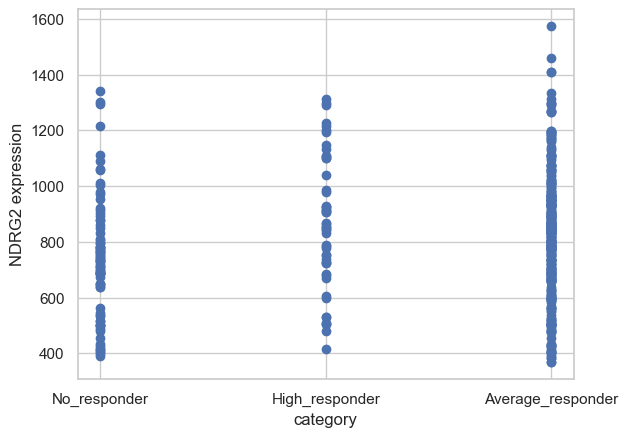

In [326]:
#Extract the important features 
plt.scatter(df["category"], df["NDRG2"])
plt.ylabel('NDRG2 expression')
plt.xlabel('category')
#plt.title('Study by change in muscle mass (%)')
plt.show()


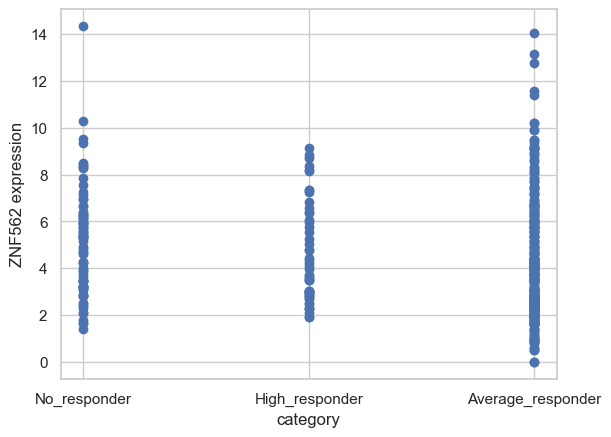

In [327]:
#Extract the important features 
plt.scatter(df["category"], df["ZNF562"])
plt.ylabel('ZNF562 expression')
plt.xlabel('category')
#plt.title('Study by change in muscle mass (%)')
plt.show()


In [237]:
# Load saved models
#model1 = tf.keras.models.load_model("best_weight_model.keras")
#model2 = tf.keras.models.load_model("best_smote_model.keras")
#model3 = joblib.load("lgbm_model.joblib")

# Get predictions
#pred1 = model1.predict(X_test_scaled)
#pred2 = model2.predict(X_test_scaled)
#pred3 = model3.predict_proba(X_test_scaled)

# Average predictions
#ensemble_pred = (pred1 + pred2 + pred3) / 3
#final_pred = np.argmax(ensemble_pred, axis=1)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


In [238]:
#print(classification_report(
#    y_test, final_pred,
#    target_names=["No_responder", "Average_responder", "High_responder"],
#    digits=3, zero_division=0
#))

                   precision    recall  f1-score   support

     No_responder      0.250     0.412     0.311        17
Average_responder      0.766     0.742     0.754        66
   High_responder      1.000     0.100     0.182        10

         accuracy                          0.613        93
        macro avg      0.672     0.418     0.416        93
     weighted avg      0.697     0.613     0.611        93



In [18]:
X_train_df.columns

Index(['TSPAN6', 'DPM1', 'SCYL3', 'CFH', 'FUCA2', 'GCLC', 'NFYA', 'NIPAL3',
       'LAS1L', 'ENPP4',
       ...
       'ENSG00000310523', 'WASH7P', 'WASH9P', 'ENSG00000310533', 'BMI', 'age',
       'sequencing_depth', 'volume', 'sex_female', 'sex_male'],
      dtype='object', length=11231)

InvalidIndexError: (slice(None, None, None), 0)